In [ ]:
!pip -q install rdkit
!pip -q install py3Dmol

In [ ]:
!mkdir -p "lab3" # use this folder to store our data

# API Access to Online Databases
In this lab, we will use API access to download data from online databases.

API provides convenient programmatic approach to download files without many clicks. You can directly perform cleaning, analysis to the file downloaded without saving and loading files repeatedly.

The new package we will be using are
- `requests`: a library to make HTTP requests to web services and resources
- `json`: a library to handle .json files

### Importing packages
Note that you only need to import packages once, as long as your Colab session is alive.

So from now on, we will put all imported packages at the beginning.

Tip: if you made a change to the imported module, you need to restart the Notebook and redo the importing to allow the changes being imported.

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import py3Dmol
import requests # already installed on colab
import json # already installed on colab

## PubChem API
We will experience querrying data from PubChem using `requests`, saving the obtained date into files, and loading the saved files.

The key usage is `requests.get()`, which takes a string of URL and returns the content from the URL.
When you do `print requests.get(url)`, you see something like `<Response [200]>`, the number codes corresponds to
| Code | Meaning                                |
| ---- | -------------------------------------- |
| 200  | OK – success                           |
| 400  | Bad request (invalid query)            |
| 401  | Unauthorized (missing/invalid API key) |
| 403  | Forbidden                              |
| 404  | Not found                              |
| 429  | Too many requests (rate limit)         |
| 500  | Server error                           |


Quiz: What is the difference between `requests` and `wget`?

### Querrying an SDF file
An SDF file stores one or multiple small-molecule structures with properties.

In [ ]:
# Query by compound name
compound_name = "aspirin"
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound_name}/SDF"
r = requests.get(url)

# let's see if we successfully received the data
status_code = r.status_code
if status_code == 200:
    print("Successfully received the data!")
else:
    print("Request failed:", r.status_code)

Successfully received the data!


In [ ]:
# save the SDF data into a file
# the content here is in binary, so we use the "b" flag
with open("lab3/aspirin_pubchem.sdf", "wb") as f: # "wb": "w" for "write mode", "b" for binary mode
    f.write(r.content)

In [ ]:
# Load SDF with RDKit
supplier = Chem.SDMolSupplier("lab3/aspirin_pubchem.sdf")
# remember there can be multiple molecules in .sdf file.
mols = []
for mol in supplier:
    if mol is not None:
        mols.append(mol)
# mols = [mol for mol in supplier if mol is not None] # one-line option to the above
print(f"There are {len(mols)} molecules in the SDF file.")
mol = mols[0] # we know there is only one molecule

There are 1 molecules in the SDF file.


Let's see what content this file has.

In [ ]:
property_list = list(mol.GetPropNames())
print("Properties provided in this sdf file: \n", property_list)

Properties provided in this sdf file: 
 ['PUBCHEM_COMPOUND_CID', 'PUBCHEM_COMPOUND_CANONICALIZED', 'PUBCHEM_CACTVS_COMPLEXITY', 'PUBCHEM_CACTVS_HBOND_ACCEPTOR', 'PUBCHEM_CACTVS_HBOND_DONOR', 'PUBCHEM_CACTVS_ROTATABLE_BOND', 'PUBCHEM_CACTVS_SUBSKEYS', 'PUBCHEM_IUPAC_OPENEYE_NAME', 'PUBCHEM_IUPAC_CAS_NAME', 'PUBCHEM_IUPAC_NAME_MARKUP', 'PUBCHEM_IUPAC_NAME', 'PUBCHEM_IUPAC_SYSTEMATIC_NAME', 'PUBCHEM_IUPAC_TRADITIONAL_NAME', 'PUBCHEM_IUPAC_INCHI', 'PUBCHEM_IUPAC_INCHIKEY', 'PUBCHEM_XLOGP3', 'PUBCHEM_EXACT_MASS', 'PUBCHEM_MOLECULAR_FORMULA', 'PUBCHEM_MOLECULAR_WEIGHT', 'PUBCHEM_SMILES', 'PUBCHEM_CONNECTIVITY_SMILES', 'PUBCHEM_CACTVS_TPSA', 'PUBCHEM_MONOISOTOPIC_WEIGHT', 'PUBCHEM_TOTAL_CHARGE', 'PUBCHEM_HEAVY_ATOM_COUNT', 'PUBCHEM_ATOM_DEF_STEREO_COUNT', 'PUBCHEM_ATOM_UDEF_STEREO_COUNT', 'PUBCHEM_BOND_DEF_STEREO_COUNT', 'PUBCHEM_BOND_UDEF_STEREO_COUNT', 'PUBCHEM_ISOTOPIC_ATOM_COUNT', 'PUBCHEM_COMPONENT_COUNT', 'PUBCHEM_CACTVS_TAUTO_COUNT', 'PUBCHEM_COORDINATE_TYPE', 'PUBCHEM_BONDANNOTATIONS'

Let's look at one of the properties: $\log P$

In [ ]:
logp = mol.GetProp("PUBCHEM_XLOGP3")
print(f"LogP of aspirin: {logp}")

LogP of aspirin: 1.2


With the above approach, you could make your own dataset!

### Querry multiple molecules



In [ ]:
# request CIDs for molecules with weights between [400.0, 400.2]
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/molecular_weight/range/400.0/400.2/cids/JSON" # now we have a JSON file
r = requests.get(url)
# let's see if we successfully received the data
status_code = r.status_code
if status_code == 200:
    print("Successfully received the data!")
else:
    print("Request failed:", r.status_code)

Successfully received the data!


In [ ]:
# save to a json file
data = r.json()
with open("lab3/pubchem_cids_mw400_0_to_400_2.json", "w") as f: # json is text-based, not binary
    json.dump(data, f, indent=2)

In [ ]:
# load the file
with open("lab3/pubchem_cids_mw400_0_to_400_2.json", "r") as f:
    data = json.load(f)

# let's see what keys it have
print(list(data.keys()))

['IdentifierList']


In [ ]:
print(data["IdentifierList"]) # still a dictionary, so we need to go deeper...

{'CID': [237, 29563, 9887206, 67734, 22882, 9552, 10662, 446536, 11704019, 20055238, 161534, 15930820, 78975, 67543, 101640, 102236, 3003674, 3003676, 23646669, 44312236, 135566513, 6096793, 6096823, 23012, 20056867, 23234364, 25138016, 71550248, 5328676, 21202952, 168294289, 453296, 2744468, 5077519, 5271735, 5271745, 1342578, 10763496, 1118419, 1378451, 6603979, 9566750, 9822294, 9978303, 10431085, 11188772, 11589399, 15981916, 15983838, 18172403, 18668832, 25221145, 44425209, 44427135, 44427137, 46896782, 53239978, 69936228, 126711433, 135897877, 137633294, 137633992, 137634876, 137653103, 152337535, 6320492, 221051, 2782409, 2782410, 68405100, 70793990, 70794015, 134229426, 134457972, 162509632, 25257, 267555, 3034070, 357621, 110217, 49791625, 9421, 56603815, 48032, 1258415, 1325823, 1356383, 1422506, 1482697, 2282018, 2377530, 3390704, 4345669, 5730819, 6603003, 6622517, 9550810, 9564730, 9572530, 10453578, 11475055, 11749932, 15944746, 16099260, 22430462, 24180481, 24828870, 248

In [ ]:
cids = data["IdentifierList"]["CID"]
print("Number of CIDs:", len(cids))

Number of CIDs: 16665


We querried quite a lot of molecules in a small MW window!

With the above CIDs, you can querry molecules, as we have shown earlier.

In [ ]:
# Example
cid_str = cids[0]
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid_str}/SDF"
r = requests.get(url)
r.raise_for_status() # error will be raised if not successful
with open(f"lab3/pubchem_cid{cid_str}.sdf", "wb") as f:
    f.write(r.content)

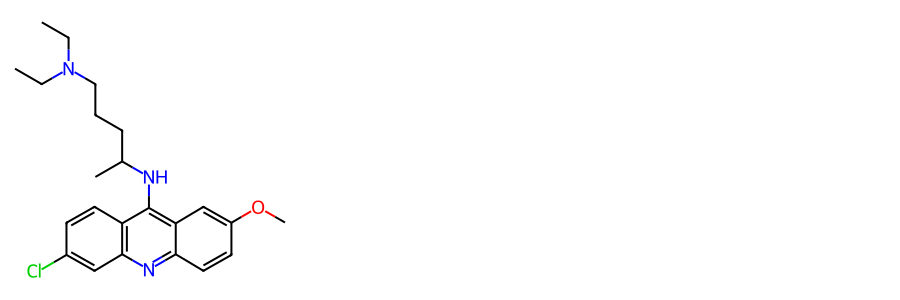

In [ ]:
supplier = Chem.SDMolSupplier(f"lab3/pubchem_cid{cid_str}.sdf")
mols = [mol for mol in supplier if mol is not None]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,300)) # draw multiple molecules (we only have one here...)

## Putting two molecules together into one SDF file

In [ ]:
sdf1 = "lab3/aspirin_pubchem.sdf"
sdf2 = f"lab3/pubchem_cid{cid_str}.sdf"

# Load molecules from both files
supplier1 = Chem.SDMolSupplier(sdf1)
supplier2 = Chem.SDMolSupplier(sdf2)

mols1 = [mol for mol in supplier1 if mol is not None]
mols2 = [mol for mol in supplier2 if mol is not None]

print(f"Loaded {len(mols1)} molecules from {sdf1}")
print(f"Loaded {len(mols2)} molecules from {sdf2}")

# Combine all molecules
all_mols = mols1 + mols2 # this is how you combine two lists into one

# Write to a new combined SDF
combined_sdf = "lab3/combined_two_moles.sdf"
writer = Chem.SDWriter(combined_sdf)

for mol in all_mols:
    writer.write(mol)

writer.close() # remember to close the file
print(f"Saved {len(all_mols)} molecules to {combined_sdf}")

Loaded 1 molecules from lab3/aspirin_pubchem.sdf
Loaded 1 molecules from lab3/pubchem_cid237.sdf
Saved 2 molecules to lab3/combined_two_moles.sdf


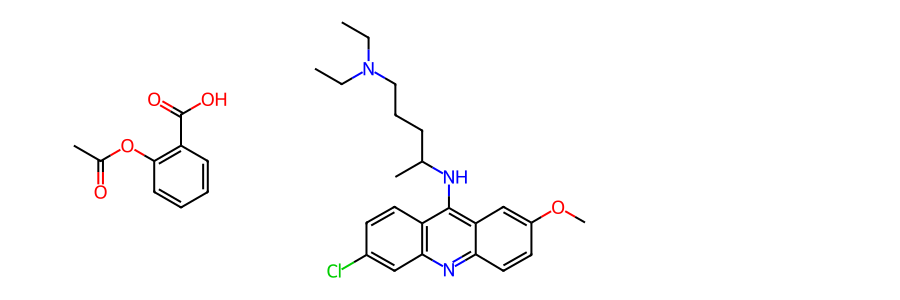

In [ ]:
# visualize them
supplier = Chem.SDMolSupplier("lab3/combined_two_moles.sdf")
mols = [mol for mol in supplier if mol is not None] # remember there can be multiple molecules in .sdf file.
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,300)) # draw multiple molecules (we only have one here...)

### Use batched downloading!
Now you have over 10k CIDs, you can write a for-loop to download every single molecule. However, that can exceed the API access limit!

A more proper way is to divide these 10k+ downloads into batches, and then download a small batch a time.

Example code
```python
batch_size = 100
n_batch = len(cids) // batch_size + 1
for nb in range(n_batch):
    for i in range(batch_size):
        idx = nb * batch_size + i
        cid_str = cids[idx]
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid_str}/SDF"
        r = requests.get(url)
        r.raise_for_status()
        with open(f"lab3/pubchem_cid{cid_str}.sdf", "wb") as f:
            f.write(r.content)
```
We will not run the above in this Lab:) But you are free to try it out.


# PDB API
We will briefly access data on PDB.

Some PDB IDs you can try out: 2PGH, 3PEL, 3GOU, 6IHX, 1G08, 1G09, 1G0A, 2QSP, 5C6E, 9RXG, 2QLS, 3PI8, 3PI9, 3PIA, 1FSX, 1QPW, 6II1, 1NGK, 1G0B, 4YU3, 1FHJ, 1HBR, 2D5X, 2QSS, 3D4X


In [ ]:
pdb_id = "1TUP"  # This is TUMOR SUPPRESSOR P53 COMPLEXED WITH DNA: https://www.rcsb.org/structure/1TUP
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
r = requests.get(url)
r.raise_for_status()
pdb_content = r.text  # PDB file content as string
print(pdb_content)

HEADER    ANTITUMOR PROTEIN/DNA                   11-JUL-95   1TUP              
TITLE     TUMOR SUPPRESSOR P53 COMPLEXED WITH DNA                               
CAVEAT     1TUP    INCORRECT CHIRAL CENTER(S)                                   
COMPND    MOL_ID: 1;                                                            
COMPND   2 MOLECULE: DNA (5'-                                                   
COMPND   3 D(*TP*TP*TP*CP*CP*TP*AP*GP*AP*CP*TP*TP*GP*CP*CP*CP*A P*AP*TP*TP*A)-  
COMPND   4 3');                                                                 
COMPND   5 CHAIN: E;                                                            
COMPND   6 ENGINEERED: YES;                                                     
COMPND   7 MOL_ID: 2;                                                           
COMPND   8 MOLECULE: DNA (5'-                                                   
COMPND   9 D(*AP*TP*AP*AP*TP*TP*GP*GP*GP*CP*AP*AP*GP*TP*CP*TP*A P*GP*GP*AP*A)-  
COMPND  10 3');             

### Visualize with Py3DMol

In [ ]:

view = py3Dmol.view(width=500, height=600)
view.addModel(pdb_content, 'pdb')  # Load PDB content
view.setStyle({'cartoon': {'color':'spectrum'}})  # Cartoon style for proteins
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Extra: Extract Data from PDF
We will briefly shown an example of extracting table from PDF.

Caution: you should always double-check the output!

The package used: `pdfplumber`.

In [ ]:
!pip install pdfplumber -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 131.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 100.8 MB/s eta 0:00:00


In [ ]:
!wget -q "https://github.com/SunLab-Rutgers/chem542_CDS/raw/main/labs/lab3/example_paper.pdf" -O "lab3/example_paper.pdf"

In [ ]:
import pdfplumber
import pandas as pd

In [ ]:
pdf_path = "lab3/example_paper.pdf"

with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[3]          # select page 4 (0-indexed)
    table = page.extract_table() # attempt to extract a table
# Let's see what we got
print(table) # extracting a table row-by-row


[['Pre-trainingdatasets'], ['Name Element #Train #Test #Total Weight'], [''], ['Alloy 53 71,482 1240 72,722 2.0'], ['Cathode-P Li,Na,O,Mn,Fe,Co,Cr,Ni 58,690 6451 65,141 1.0'], ['Cluster-P Pd,Ru,Al,Au,Ag,Pt,Si,Cu,Ni 139,200 14,936 154,136 1.0'], ['Drug H,C,N,O,F,Cl,S,P 1,379,956 24,257 1,404,213 2.0'], ['FerroEle-P 15 6966 760 7726 1.0'], ['OC2M 56 2,000,000 999,866 2,999,866 2.0'], ['SSE-PBE-P Li,P,S,Si,Ge 15,019 755 15,774 1.0'], ['SemiCond-P 14 136,867 14,848 151,715 1.0'], ['H2O-PD H,O 46,077 2342 48,419 1.0'], ['Ag∪Au-PBE Ag,Au 16,696 812 17,508 0.2'], ['Al∪Mg∪Cu Al,Mg,Cu 24,252 1145 25,397 0.3'], ['Cu Cu 14,596 770 15,366 0.1'], ['Sn Sn 6449 276 6725 0.1'], ['Ti Ti 10,054 474 10,528 0.1'], ['V V 14,935 738 15,673 0.1'], ['W W 42,297 2100 44,397 0.1'], ['C12H26 H,C 33,898 1598 35,496 0.1'], ['HfO2 O,Hf 27,660 917 28,577 0.1'], ['sum 73 4,045,094 1,074,285 5,119,379 13.2'], ['Downstreamdatasets'], ['Name Element #Train #Test #Total Weight'], [''], ['Cathode-D Li,Na,O,Mn,Fe,Co,Cr 30,

In [ ]:
# Convert to DataFrame
# we do not want the first row
df = pd.DataFrame(table[3:], columns=table[1])
print(df.head())

             Name Element #Train #Test #Total Weight
0                    Alloy 53 71,482 1240 72,722 2.0
1  Cathode-P Li,Na,O,Mn,Fe,Co,Cr,Ni 58,690 6451 6...
2  Cluster-P Pd,Ru,Al,Au,Ag,Pt,Si,Cu,Ni 139,200 1...
3  Drug H,C,N,O,F,Cl,S,P 1,379,956 24,257 1,404,2...
4                    FerroEle-P 15 6966 760 7726 1.0


In [ ]:
df.to_csv("Table1_from_pdf.csv", index=False)